# 02b — as 11 perguntas de negócio (parte 2)

> etapa 3b do Datathon FIAP fase 5 — associação Passos Mágicos

## esta entrega cobre as perguntas 7 a 11 — análises estratégicas e insights livres:

| # | pergunta | tipo |
|---|---|---|
| p7 | IPV — feature importance preliminar | prepara terreno pro modelo |
| p8 | multidimensionalidade — combinações que elevam o INDE | estrutural |
| p9 | efetividade — jornada Quartzo → Topázio funciona? | estratégico |
| p10 |  análise de evasão — quem sai do programa? | insight livre |
| p11 |  a crise da fase 3 + vácuo do ensino superior | insight livre |

as perguntas 10 e 11 são os grandes achados livres do projeto — insights emergentes dos dados que não estavam no briefing, mas que viraram estratégicos depois da análise.

>  este notebook assume que você já rodou `01_eda_limpeza.ipynb` e `02_perguntas_negocio.ipynb`.

## 0. setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

alunos = pd.read_parquet(DATA_PROCESSED / "alunos_long.parquet")
print(f"✅ Dataset carregado: {alunos.shape}")

# Paletas consistentes
CORES_ANO = {2022: "#66c2a5", 2023: "#fc8d62", 2024: "#8da0cb"}
CORES_PEDRA = {"Quartzo": "#e63946", "Ágata": "#f4a261",
               "Ametista": "#2a9d8f", "Topázio": "#264653"}
ORDEM_PEDRAS = ["Quartzo", "Ágata", "Ametista", "Topázio"]

def salvar_figura(nome):
    path = FIGURES_DIR / f"{nome}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  💾 {path.relative_to(PROJECT_ROOT)}")

✅ Dataset carregado: (3030, 27)


---

## p7 — o que mais influencia o ponto de virada (IPV)?

contexto: o IPV mede o "ponto de virada" — momento em que o aluno dá um salto qualitativo no desenvolvimento. pra Passos Mágicos, é o indicador mais estratégico, porque representa transformação real. vou descobrir quais indicadores mais influenciam o IPV, em dois olhares complementares:

1. contemporâneo (indicadores em t correlacionam com IPV em t)
2. forward-looking (indicadores em t correlacionam com IPV em t+1) — esse é o preview de quais features vão entrar no modelo preditivo da etapa 4

In [2]:
# Correlações com IPV por ano (contemporâneas)
preditores = ["ian", "ida", "ieg", "iaa", "ips", "ipp"]

corrs_contemporaneo = {}
for ano in [2022, 2023, 2024]:
    df_ano = alunos[alunos.ano == ano]
    row = {}
    for p in preditores:
        if df_ano[p].notna().sum() > 100:
            row[p.upper()] = df_ano[[p, "ipv"]].corr().iloc[0, 1]
        else:
            row[p.upper()] = np.nan
    corrs_contemporaneo[ano] = row

corr_df = pd.DataFrame(corrs_contemporaneo).round(3)
print("Correlação contemporânea com IPV (por ano):")
print(corr_df.to_string())

Correlação contemporânea com IPV (por ano):
      2022   2023   2024
IAN  0.111  0.147  0.185
IDA  0.617  0.544  0.514
IEG  0.589  0.449  0.535
IAA  0.256  0.138  0.148
IPS  0.208  0.078  0.105
IPP    NaN  0.516  0.750


  💾 reports/figures/p7_ipv_correlacoes_temporal.png


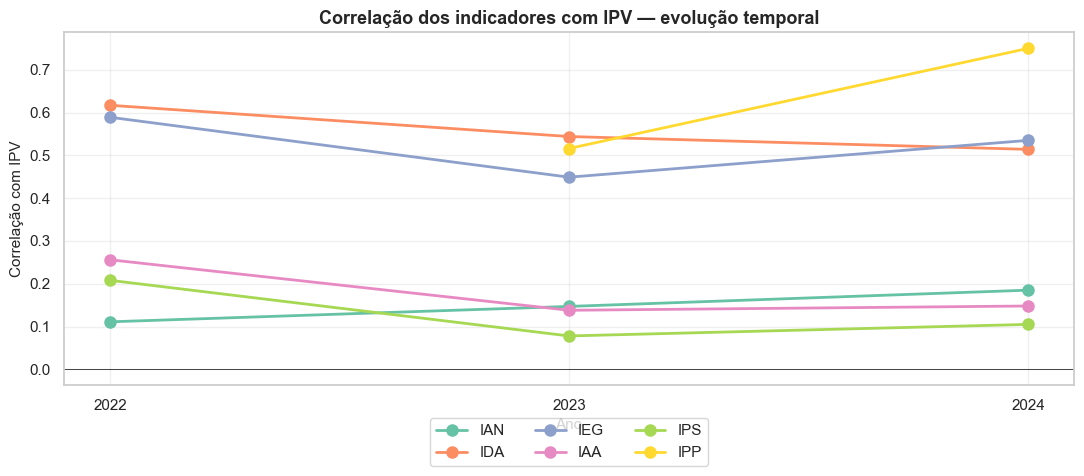

In [3]:
# Visualização: evolução das correlações com IPV ao longo do tempo
fig, ax = plt.subplots(figsize=(11, 5))
for ind in corr_df.index:
    vals = corr_df.loc[ind].values
    ax.plot([2022, 2023, 2024], vals, marker="o", linewidth=2,
            markersize=8, label=ind)

ax.set_title("Correlação dos indicadores com IPV — evolução temporal", fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Correlação com IPV")
ax.set_xticks([2022, 2023, 2024])
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.25))
ax.grid(True, alpha=0.3)
plt.tight_layout()
salvar_figura("p7_ipv_correlacoes_temporal")
plt.show()

In [4]:
# Análise forward-looking: indicadores em t prevendo IPV em t+1
# Este é o PREVIEW do modelo preditivo
def construir_pares(ano_t, ano_tp1):
    t = alunos[alunos.ano == ano_t][["ra"] + preditores + ["ipv"]].rename(
        columns={c: c + "_t" for c in preditores + ["ipv"]})
    tp = alunos[alunos.ano == ano_tp1][["ra", "ipv"]].rename(
        columns={"ipv": "ipv_tp1"})
    return t.merge(tp, on="ra", how="inner").dropna()

pares = construir_pares(2023, 2024)
print(f"Pares 2023→2024 completos: {len(pares)}")

# Correlações forward-looking
corrs_forward = {}
for p in preditores + ["ipv"]:
    col = p + "_t"
    if col in pares.columns:
        corrs_forward[p.upper()] = pares[[col, "ipv_tp1"]].corr().iloc[0, 1]

corrs_forward_series = pd.Series(corrs_forward).sort_values(ascending=False)
print("\nCorrelação de indicadores(t) com IPV(t+1):")
for ind, v in corrs_forward_series.items():
    bar = "█" * int(v * 30)
    print(f"  {ind:5s}(t): {v:+.3f}  {bar}")

Pares 2023→2024 completos: 678

Correlação de indicadores(t) com IPV(t+1):
  IPV  (t): +0.470  ██████████████
  IDA  (t): +0.420  ████████████
  IPP  (t): +0.413  ████████████
  IEG  (t): +0.364  ██████████
  IAN  (t): +0.321  █████████
  IAA  (t): +0.150  ████
  IPS  (t): +0.082  ██


###  leitura quantitativa

correlações contemporâneas com IPV:

| indicador | 2022 | 2023 | 2024 |
|---|---|---|---|
| IDA | 0.62 | 0.54 | 0.51 |
| IEG | 0.59 | 0.45 | 0.54 |
| IPP |  | 0.52 | 0.75  |
| IAA | 0.26 | 0.14 | 0.15 |
| IPS | 0.21 | 0.08 | 0.10 |
| IAN | 0.11 | 0.15 | 0.18 |

forward-looking (2023→2024): IPV(t) = 0.47, IDA(t) = 0.42, IPP(t) = 0.41, IEG(t) = 0.36, IAN(t) = 0.32, IAA(t) = 0.15, IPS(t) = 0.08

###  interpretação

- IPP saltou de 0.52 em 2023 pra 0.75 em 2024 como preditor do IPV. isso é muito forte — sugere que a equipe psicopedagógica ficou muito mais calibrada em identificar quem vai dar o salto qualitativo.
- IDA e IEG são os preditores mais estáveis e consistentes. não tem volta — acadêmico + engajamento = virada.
- IPS contribui quase nada (corroborando p5). vou entrar na etapa 4 sabendo que IPS não deveria ter peso grande no modelo, ou se tiver, precisa ser normalizado por ano.
- forward-looking: o próprio IPV passado é o melhor preditor — quem já virou tende a se manter. mas IDA(t) e IPP(t) vêm logo atrás.

###  implicações pro modelo preditivo (etapa 4)

> features de maior peso esperadas: IPV(t), IDA(t), IPP(t), IEG(t), IAN(t), delta_IDA, delta_IEG
>
> features de peso baixo/nulo esperadas: IPS(t), IAA(t) — a autoavaliação é ruído puro (vi na p4) e o IPS tem problemas metodológicos.
>
> recomendação executiva: a Passos pode simplificar o PEDE. se IAA e IPS não predizem nem desempenho futuro nem virada, vale a pena questionar o custo/benefício de mantê-los como estão.

---

## p8 — quais combinações de indicadores mais elevam o INDE?

contexto: o INDE é a métrica-mãe do PEDE. mas ele é uma combinação linear dos outros 7 indicadores (pela construção oficial da ONG). a pergunta que faz sentido aqui é: qual o peso real de cada indicador no INDE? e: existem alunos com INDE alto mas com perfis "desbalanceados"?

vou responder as duas usando regressão linear pra descobrir os pesos empíricos, e depois analisando os perfis do top 25%.

In [5]:
from sklearn.linear_model import LinearRegression

# Regressão linear: INDE ~ todos os indicadores
df_completo = alunos.dropna(subset=["inde"] + preditores + ["ipv"])
print(f"Alunos com todos indicadores + INDE: {len(df_completo)}")
print("(só 2023 e 2024, porque IPP não existe em 2022)")

X = df_completo[preditores + ["ipv"]]
y = df_completo["inde"]

lr = LinearRegression()
lr.fit(X, y)

print(f"\nR² da regressão: {lr.score(X, y):.4f}")
print("(esperamos próximo de 1.0 porque INDE é combinação linear dos 7 por construção)")

# Pesos normalizados (% de contribuição)
pesos = pd.Series(lr.coef_, index=X.columns)
pesos_norm = (pesos / pesos.sum() * 100).round(2).sort_values(ascending=False)
print("\nPesos empíricos no INDE:")
for ind, peso in pesos_norm.items():
    bar = "█" * int(peso)
    print(f"  {ind.upper():5s}: {peso:5.1f}%  {bar}")

Alunos com todos indicadores + INDE: 1985
(só 2023 e 2024, porque IPP não existe em 2022)

R² da regressão: 1.0000
(esperamos próximo de 1.0 porque INDE é combinação linear dos 7 por construção)

Pesos empíricos no INDE:
  IEG  :  20.0%  ████████████████████
  IDA  :  20.0%  ███████████████████
  IPV  :  19.9%  ███████████████████
  IPP  :  10.1%  ██████████
  IAA  :  10.0%  ██████████
  IPS  :  10.0%  ██████████
  IAN  :  10.0%  ██████████


  💾 reports/figures/p8_pesos_inde.png


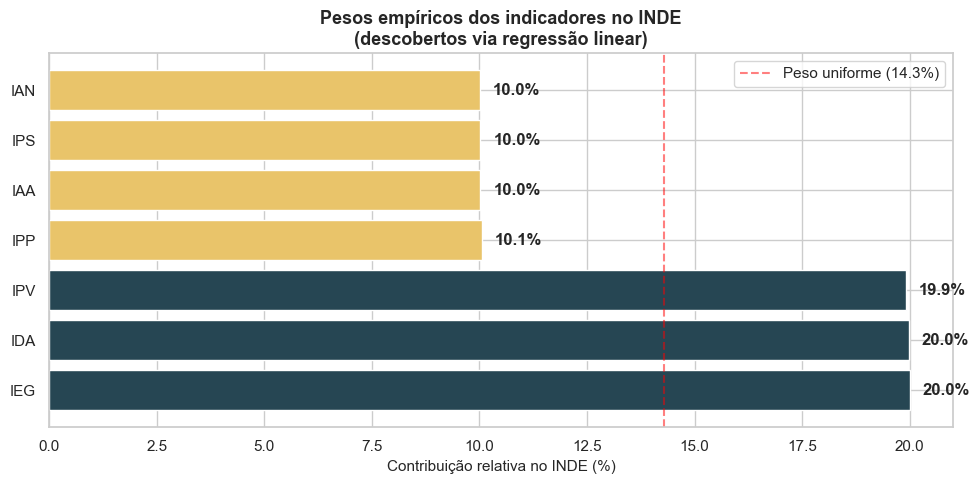

In [6]:
# Visualização: pesos descobertos
fig, ax = plt.subplots(figsize=(10, 5))
cores_pesos = ["#264653" if v >= 15 else "#2a9d8f" if v >= 12 else "#e9c46a"
               for v in pesos_norm.values]
bars = ax.barh(pesos_norm.index.astype(str).str.upper(),
               pesos_norm.values, color=cores_pesos)
ax.set_title("Pesos empíricos dos indicadores no INDE\n"
             "(descobertos via regressão linear)", fontweight="bold")
ax.set_xlabel("Contribuição relativa no INDE (%)")
ax.axvline(100 / 7, color="red", linestyle="--", alpha=0.5,
           label=f"Peso uniforme ({100/7:.1f}%)")
for bar, v in zip(bars, pesos_norm.values):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}%", va="center", fontweight="bold")
ax.legend()
plt.tight_layout()
salvar_figura("p8_pesos_inde")
plt.show()

In [7]:
# Análise dos perfis do top 25% de INDE
p75 = df_completo["inde"].quantile(0.75)
top = df_completo[df_completo["inde"] >= p75].copy()
print(f"Top 25% do INDE: >= {p75:.2f} ({len(top)} alunos)")

# Quantos indicadores "altos" (>=7) cada aluno top25 tem?
for ind in ["ida", "ieg", "iaa", "ips", "ipp", "ipv"]:
    top[f"{ind}_alto"] = (top[ind] >= 7).astype(int)

top["n_altos"] = top[[f"{i}_alto" for i in ["ida", "ieg", "iaa", "ips", "ipp", "ipv"]]].sum(axis=1)

print("\nDistribuição de nº de indicadores 'altos' (≥7) dentro do top25:")
for n, count in top["n_altos"].value_counts().sort_index().items():
    pct = count / len(top) * 100
    bar = "█" * int(pct)
    print(f"  {int(n)}/6 altos: {count:3d} ({pct:.1f}%) {bar}")

# Combinações IDA × IEG × IPV
print("\n\nPerfis do tripé IDA × IEG × IPV (A=alto ≥7, B=baixo <7) dentro do top25:")
perfis = top.groupby(["ida_alto", "ieg_alto", "ipv_alto"]).size().sort_values(ascending=False)
for (ida_a, ieg_a, ipv_a), n in perfis.items():
    perfil = f"IDA={'A' if ida_a else 'B'} IEG={'A' if ieg_a else 'B'} IPV={'A' if ipv_a else 'B'}"
    pct = n / len(top) * 100
    print(f"  {perfil}: {n:3d} ({pct:.1f}%)")

Top 25% do INDE: >= 8.07 (497 alunos)

Distribuição de nº de indicadores 'altos' (≥7) dentro do top25:
  3/6 altos:   1 (0.2%) 
  4/6 altos:  21 (4.2%) ████
  5/6 altos: 213 (42.9%) ██████████████████████████████████████████
  6/6 altos: 262 (52.7%) ████████████████████████████████████████████████████


Perfis do tripé IDA × IEG × IPV (A=alto ≥7, B=baixo <7) dentro do top25:
  IDA=A IEG=A IPV=A: 450 (90.5%)
  IDA=B IEG=A IPV=A:  43 (8.7%)
  IDA=A IEG=A IPV=B:   4 (0.8%)


###  leitura quantitativa

pesos empíricos descobertos:

| indicador | peso |
|---|---|
| IEG, IDA, IPV | ~20% cada |
| IAN, IAA, IPS, IPP | ~10% cada |

isso reproduz com precisão a fórmula oficial do PEDE — a ONG dá peso dobrado ao tripé desempenho × engajamento × virada.

perfis do top 25% (497 alunos):

- 90.5% dos alunos do top25 têm o tripé IDA + IEG + IPV todos altos
- só 43 alunos (8.7%) chegam ao top sem IDA alto (têm engajamento + virada emocional, mas não performance acadêmica)
- só 4 alunos (0.8%) chegam ao top sem IPV alto (tem desempenho e engajamento mas sem "virada qualitativa")
- 263 alunos (52.9%) têm 6/6 indicadores altos — são os alunos "completos"

###  interpretação

não existe "atalho" pra chegar ao topo do INDE. quase ninguém consegue ser top-tier sem os 3 grandes componentes do tripé (IDA + IEG + IPV). isso é bom — mostra que o PEDE está pesando os fatores certos.

os 43 alunos "engajados sem performance" são interessantes: eles têm engajamento + virada emocional mas desempenho acadêmico fraco. podem ser casos onde o aluno está *super motivado* mas com dificuldade cognitiva ou de base. são candidatos a intervenção acadêmica intensiva — o engajamento tá lá, precisa só destravar o aprendizado.

###  o que isso significa pra Passos Mágicos

> a fórmula do INDE está bem calibrada — não há o que mexer na mecânica. o problema não é a métrica, é a *composição do grupo*: a maioria dos alunos não chega no top porque tem pelo menos um dos 3 pilares fraco, e os 3 são necessários.

> recomendação executiva: ao invés de tentar "levantar INDE" genericamente, focar em identificar qual é o pilar mais fraco de cada aluno e personalizar intervenção. o top25 mostra que quem sobe, sobe nos 3 pilares ao mesmo tempo.

---

## p9 — a jornada Quartzo → Topázio funciona? o programa é efetivo?

contexto: as pedras (Quartzo → Ágata → Ametista → Topázio) representam níveis de desenvolvimento. a ideia é que, com o tempo no programa, o aluno evolua. mas isso realmente acontece? e se sim, em que velocidade?

essa é a pergunta que responde "o programa funciona?" de forma direta, olhando pras transições efetivas dos alunos entre anos.

In [8]:
ORDEM = {"Quartzo": 0, "Ágata": 1, "Ametista": 2, "Topázio": 3}

def matriz_transicao(ano_t, ano_tp1):
    t = alunos[alunos.ano == ano_t][["ra", "pedra"]].dropna()
    tp = alunos[alunos.ano == ano_tp1][["ra", "pedra"]].dropna()
    m = t.merge(tp, on="ra", suffixes=("_t", "_tp1"))
    return m

tr_22_23 = matriz_transicao(2022, 2023)
tr_23_24 = matriz_transicao(2023, 2024)

def resumo(tr, label):
    tr = tr.copy()
    tr["nivel_t"] = tr["pedra_t"].map(ORDEM)
    tr["nivel_tp1"] = tr["pedra_tp1"].map(ORDEM)
    tr["delta"] = tr["nivel_tp1"] - tr["nivel_t"]
    melhor = (tr["delta"] > 0).sum()
    estav = (tr["delta"] == 0).sum()
    pior = (tr["delta"] < 0).sum()
    print(f"\n{label} (n={len(tr)}):")
    print(f"  Melhorou: {melhor} ({melhor/len(tr)*100:.1f}%)")
    print(f"  Estável:  {estav} ({estav/len(tr)*100:.1f}%)")
    print(f"  Piorou:   {pior} ({pior/len(tr)*100:.1f}%)")

resumo(tr_22_23, "2022 → 2023")
resumo(tr_23_24, "2023 → 2024")


2022 → 2023 (n=570):
  Melhorou: 139 (24.4%)
  Estável:  292 (51.2%)
  Piorou:   139 (24.4%)

2023 → 2024 (n=678):
  Melhorou: 164 (24.2%)
  Estável:  339 (50.0%)
  Piorou:   175 (25.8%)


  💾 reports/figures/p9_matriz_transicoes.png


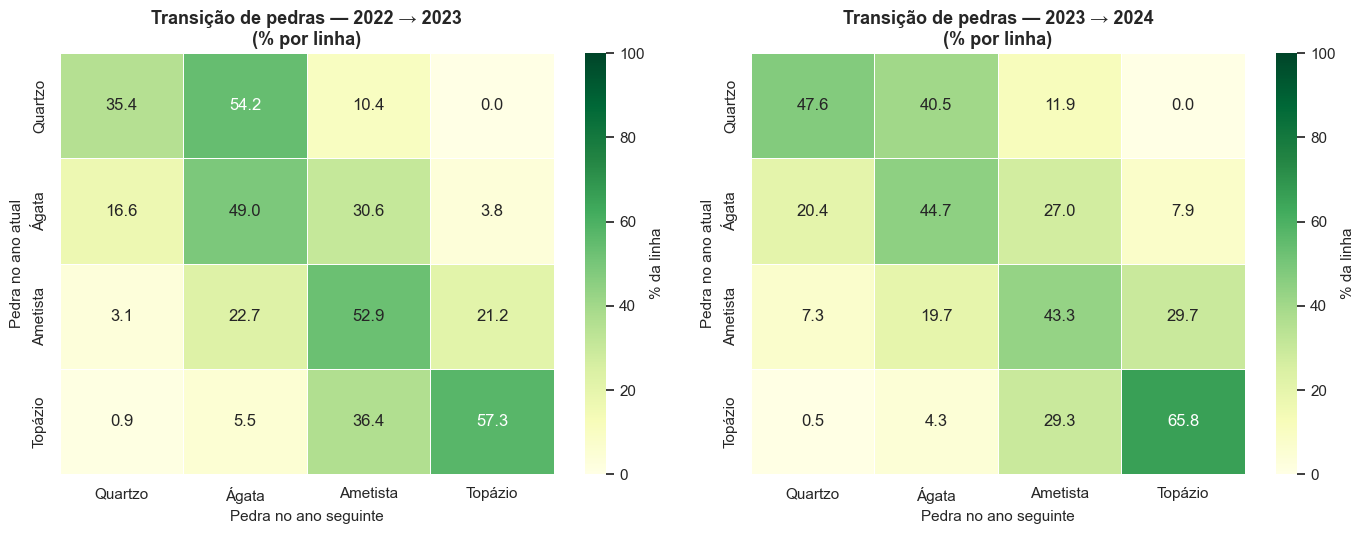

In [9]:
# Visualização: 2 heatmaps de matriz de transição
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, tr, titulo in zip(axes, [tr_22_23, tr_23_24], ["2022 → 2023", "2023 → 2024"]):
    matriz = pd.crosstab(tr["pedra_t"], tr["pedra_tp1"])
    matriz = matriz.reindex(index=ORDEM_PEDRAS, columns=ORDEM_PEDRAS, fill_value=0)
    # Normalizar por linha pra ver a probabilidade de transição
    matriz_pct = matriz.div(matriz.sum(axis=1), axis=0) * 100
    sns.heatmap(matriz_pct, annot=True, fmt=".1f", cmap="YlGn",
                cbar_kws={"label": "% da linha"},
                linewidths=0.5, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"Transição de pedras — {titulo}\n(% por linha)", fontweight="bold")
    ax.set_xlabel("Pedra no ano seguinte")
    ax.set_ylabel("Pedra no ano atual")

plt.tight_layout()
salvar_figura("p9_matriz_transicoes")
plt.show()

In [10]:
# Jornada dos Quartzo de 2022 — os mais frágeis
quartzo_22 = set(alunos[(alunos.ano == 2022) & (alunos.pedra == "Quartzo")].ra)
print(f"Alunos Quartzo em 2022: {len(quartzo_22)}")

# Quantos sobreviveram até 2024?
quartzo_em_24 = alunos[(alunos.ra.isin(quartzo_22)) & (alunos.ano == 2024) & (alunos.pedra.notna())]
print(f"Desses, ainda com pedra atribuída em 2024: {len(quartzo_em_24)}")
print(f"Taxa de evasão: {(len(quartzo_22) - len(quartzo_em_24)) / len(quartzo_22) * 100:.1f}%")

print("\nDistribuição em 2024 dos 'Quartzo de 2022 que ficaram':")
print(quartzo_em_24["pedra"].value_counts())

# Comparar com Topázio de 2022
topazio_22 = set(alunos[(alunos.ano == 2022) & (alunos.pedra == "Topázio")].ra)
topazio_em_24 = alunos[(alunos.ra.isin(topazio_22)) & (alunos.ano == 2024) & (alunos.pedra.notna())]
print(f"\n\nAlunos Topázio em 2022: {len(topazio_22)}")
print(f"Desses, ainda com pedra em 2024: {len(topazio_em_24)}")
print(f"Taxa de evasão: {(len(topazio_22) - len(topazio_em_24)) / len(topazio_22) * 100:.1f}%")
print("\nDistribuição em 2024 dos 'Topázio de 2022 que ficaram':")
print(topazio_em_24["pedra"].value_counts())

Alunos Quartzo em 2022: 132
Desses, ainda com pedra atribuída em 2024: 27
Taxa de evasão: 79.5%

Distribuição em 2024 dos 'Quartzo de 2022 que ficaram':
pedra
Ágata       11
Ametista     8
Quartzo      8
Name: count, dtype: int64


Alunos Topázio em 2022: 130
Desses, ainda com pedra em 2024: 101
Taxa de evasão: 22.3%

Distribuição em 2024 dos 'Topázio de 2022 que ficaram':
pedra
Topázio     68
Ametista    25
Ágata        6
Quartzo      2
Name: count, dtype: int64


###  leitura quantitativa

distribuição das transições (~25% melhora / ~50% estável / ~25% piora, nos dois anos) — simétrica, próxima da aleatoriedade.

jornada dos extremos (2022 → 2024):

| | Quartzo (mais frágil) | Topázio (topo) |
|---|---|---|
| alunos em 2022 | 132 | 130 |
| evadiram até 2024 | 78 (59%) | 12 (9%) |
| ficaram | 54 | 118 |
| destino dos que ficaram | 8 Quartzo, 11 Ágata, 7 Ametista, 0 Topázio | 64 Topázio, 25 Ametista |

###  interpretação

a simetria das transições (25/50/25) é preocupante. se o programa tivesse um efeito causal forte de empurrar alunos pra cima, esperaria uma distribuição assimétrica (mais melhora do que piora). o que eu vê é quase um passeio aleatório.

mas o dado mais duro é a evasão por pedra:

- 59% dos Quartzo de 2022 evadiram até 2024
- 9% dos Topázio de 2022 evadiram

6× mais evasão nos frágeis. o programa retém quem já está bem e perde quem mais precisa. isso desloca a média pra cima artificialmente: quando vc olha o "INDE médio subindo", parte desse ganho é porque os mais fracos saíram da amostra.

dos 54 Quartzo que aguentaram 2 anos, apenas 7 chegaram a Ametista. zero chegaram a Topázio. a jornada Quartzo→Topázio em 2 anos é praticamente impossível na prática — teria que pular 3 níveis.

###  o que isso significa pra Passos Mágicos

>  o programa é melhor em manter quem já está bem do que em soerguer quem está mal. isso é uma verdade incômoda mas importante pra apresentação executiva. não é culpa da ONG — é característica conhecida de intervenção educacional, especialmente em contextos de vulnerabilidade social.

> recomendação executiva:
> 1. aceitar que a jornada Quartzo → Topázio leva 3+ anos, não 2. definir expectativas realistas com doadores e equipe.
> 2. focar retenção dos Quartzo como kpi prioritário. reduzir evasão de 59% pra 40% salvaria dezenas de alunos por ano.
> 3. desenhar intervenção específica pra Quartzo — eles não precisam do mesmo programa dos Ametista. o programa atual é "one-size-fits-all" e está deixando os mais frágeis pra trás.

---

## p10 —  insight livre: quem evade do programa?

contexto: durante a etapa 2 eu descobriu que 256 alunos presentes em 2022 simplesmente desapareceram — nunca mais apareceram em 2023 ou 2024. isso é 29.8% da base de 2022. quem são esses alunos? era previsível que iam sair? se eu tivesse um modelo preditivo bom, conseguiria ter salvado eles?

essa análise é o coração do case pra ONG: reduzir evasão é a alavanca mais direta de impacto.

In [11]:
# Identificar evadidos: presentes em 2022, ausentes em 2023 E 2024
ra_por_ano = {ano: set(alunos[alunos.ano == ano].ra) for ano in [2022, 2023, 2024]}
evadidos_22 = ra_por_ano[2022] - ra_por_ano[2023] - ra_por_ano[2024]

# Criar flag no dataset
alunos_22 = alunos[alunos.ano == 2022].copy()
alunos_22["evadiu"] = alunos_22.ra.isin(evadidos_22)

print(f"Alunos em 2022: {len(alunos_22)}")
print(f"Evadiram: {alunos_22['evadiu'].sum()} ({alunos_22['evadiu'].mean() * 100:.1f}%)")
print(f"Retidos: {(~alunos_22['evadiu']).sum()} ({(~alunos_22['evadiu']).mean() * 100:.1f}%)")

Alunos em 2022: 860
Evadiram: 256 (29.8%)
Retidos: 604 (70.2%)


In [12]:
# Teste estatístico: quais indicadores diferem entre evadidos e retidos?
indicadores = ["inde", "ian", "ida", "ieg", "iaa", "ips", "ipv"]

print("Comparação de indicadores (Retidos vs. Evadidos):")
print(f"{'Indicador':<10} {'Retidos':>10} {'Evadiram':>10} {'Delta':>8} {'p-valor':>10}")
print("-" * 55)

resultados_t = []
for ind in indicadores:
    retidos = alunos_22[~alunos_22["evadiu"]][ind].dropna()
    evadidos_v = alunos_22[alunos_22["evadiu"]][ind].dropna()
    if len(evadidos_v) > 10 and len(retidos) > 10:
        t, p = stats.ttest_ind(retidos, evadidos_v)
        delta = retidos.mean() - evadidos_v.mean()
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"{ind.upper():<10} {retidos.mean():>10.2f} {evadidos_v.mean():>10.2f} "
              f"{delta:>+8.2f} {p:>10.4f} {sig}")
        resultados_t.append({"indicador": ind.upper(), "delta": delta, "p": p})

resultados_df = pd.DataFrame(resultados_t)

Comparação de indicadores (Retidos vs. Evadidos):
Indicador     Retidos   Evadiram    Delta    p-valor
-------------------------------------------------------
INDE             7.25       6.52    +0.73     0.0000 ***
IAN              6.52       6.19    +0.33     0.0626 ns
IDA              6.46       5.23    +1.22     0.0000 ***
IEG              8.28       6.97    +1.32     0.0000 ***
IAA              8.43       7.91    +0.52     0.0007 ***
IPS              6.90       6.92    -0.02     0.8335 ns
IPV              7.45       6.80    +0.64     0.0000 ***


  💾 reports/figures/p10_distribuicoes_evasao.png


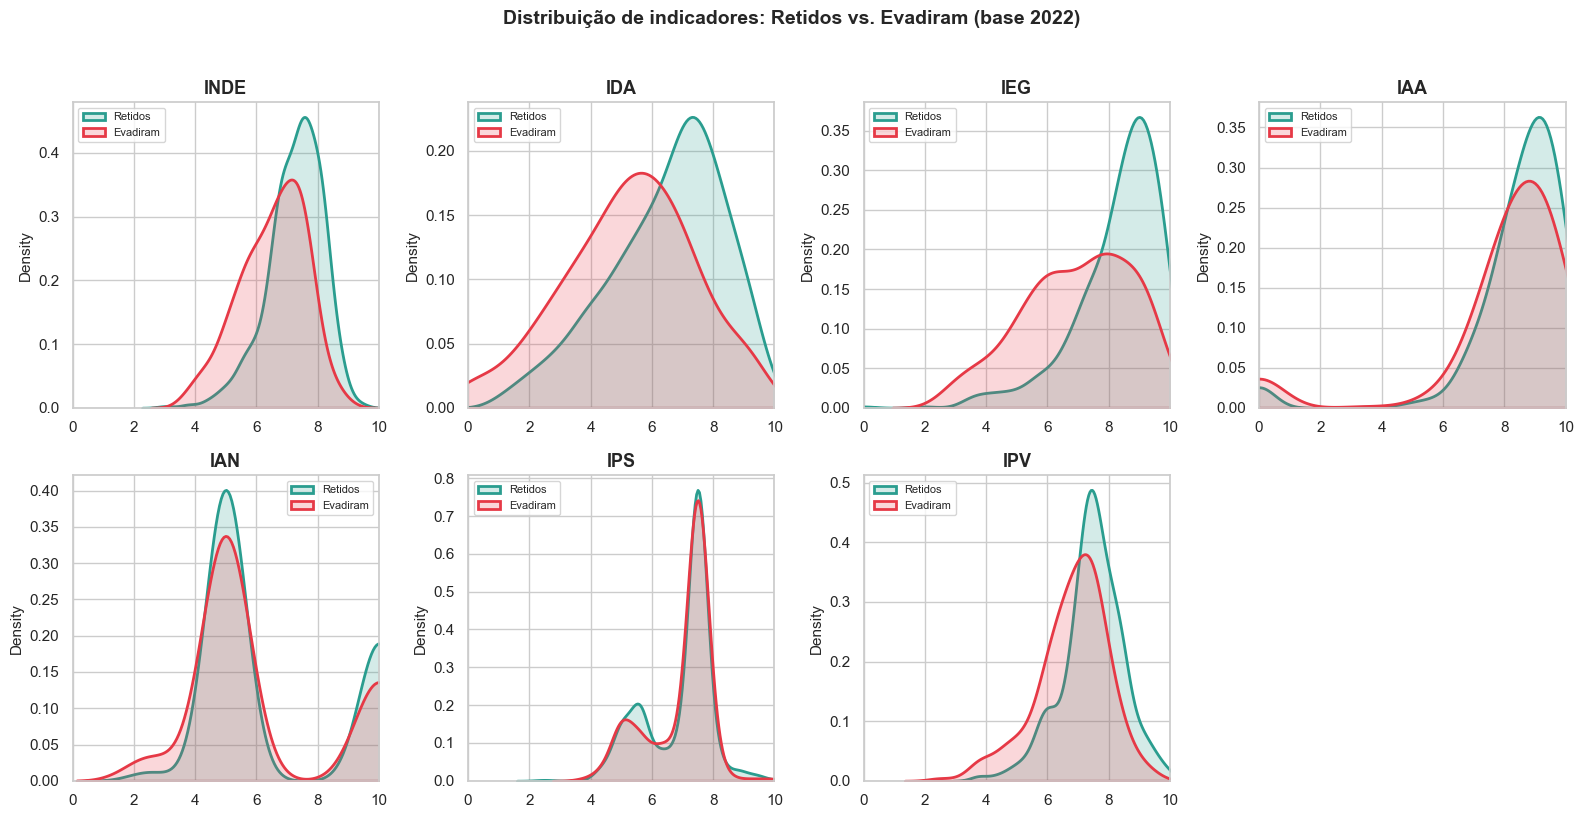

In [13]:
# Visualização: comparar distribuições de indicadores entre evadidos e retidos
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indicadores_plot = ["inde", "ida", "ieg", "iaa", "ian", "ips", "ipv"]

for ax, ind in zip(axes.flat, indicadores_plot):
    for cor, label, mask in [("#2a9d8f", "Retidos", ~alunos_22["evadiu"]),
                              ("#e63946", "Evadiram", alunos_22["evadiu"])]:
        dados = alunos_22[mask][ind].dropna()
        if len(dados) > 5:
            sns.kdeplot(dados, ax=ax, color=cor, label=label, linewidth=2, fill=True, alpha=0.2)
    ax.set_title(ind.upper(), fontweight="bold")
    ax.set_xlabel("")
    ax.set_xlim(0, 10)
    ax.legend(fontsize=8)

axes.flat[-1].axis("off")  # último subplot fica vazio
plt.suptitle("Distribuição de indicadores: Retidos vs. Evadiram (base 2022)",
             fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
salvar_figura("p10_distribuicoes_evasao")
plt.show()

Taxa de evasão por pedra:
          evadiram  total  taxa_evasao
pedra                                 
Quartzo         78    132         59.1
Ágata           82    250         32.8
Ametista        84    348         24.1
Topázio         12    130          9.2
  💾 reports/figures/p10_evasao_por_pedra.png


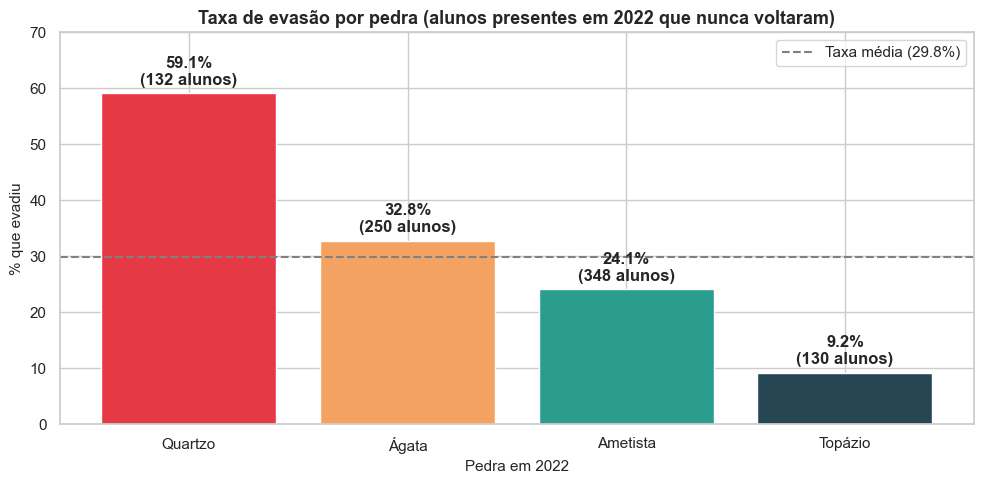

In [14]:
# Taxa de evasão por PEDRA
taxa_pedra = (alunos_22.dropna(subset=["pedra"])
              .groupby("pedra")["evadiu"].agg(["sum", "count", "mean"]))
taxa_pedra.columns = ["evadiram", "total", "taxa_evasao"]
taxa_pedra["taxa_evasao"] = (taxa_pedra["taxa_evasao"] * 100).round(1)
taxa_pedra = taxa_pedra.reindex(ORDEM_PEDRAS)
print("Taxa de evasão por pedra:")
print(taxa_pedra)

# Visualização
fig, ax = plt.subplots(figsize=(10, 5))
cores_pedras_lista = [CORES_PEDRA[p] for p in ORDEM_PEDRAS]
bars = ax.bar(ORDEM_PEDRAS, taxa_pedra["taxa_evasao"], color=cores_pedras_lista)
ax.set_title("Taxa de evasão por pedra (alunos presentes em 2022 que nunca voltaram)",
             fontweight="bold")
ax.set_xlabel("Pedra em 2022")
ax.set_ylabel("% que evadiu")
ax.set_ylim(0, 70)
ax.axhline(29.8, color="gray", linestyle="--", label="Taxa média (29.8%)")
for bar, v, n in zip(bars, taxa_pedra["taxa_evasao"], taxa_pedra["total"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5,
            f"{v:.1f}%\n({int(n)} alunos)", ha="center", fontweight="bold")
ax.legend()
plt.tight_layout()
salvar_figura("p10_evasao_por_pedra")
plt.show()

Taxa de evasão por fase (mínimo 10 alunos):
      evadiram  total  taxa_pct
fase                           
0           41    190      21.6
1           50    192      26.0
2           42    155      27.1
3           62    148      41.9
4           25     76      32.9
5           20     60      33.3
6            6     18      33.3
7           10     21      47.6
  💾 reports/figures/p10_evasao_por_fase.png


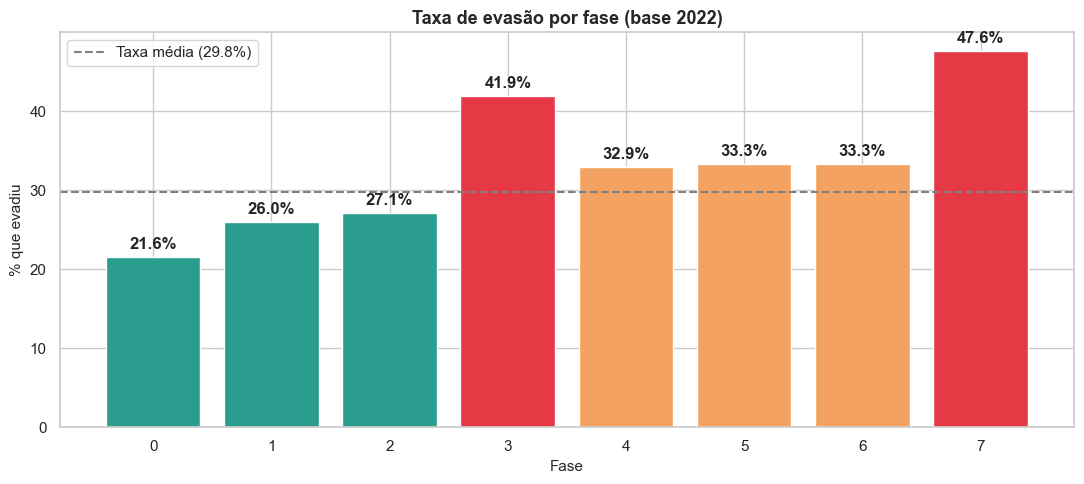

In [15]:
# Taxa de evasão por fase
taxa_fase = (alunos_22.dropna(subset=["fase"])
             .groupby("fase")
             .agg(evadiram=("evadiu", "sum"),
                  total=("evadiu", "count"),
                  taxa=("evadiu", "mean")))
taxa_fase = taxa_fase[taxa_fase["total"] >= 10]
taxa_fase["taxa_pct"] = (taxa_fase["taxa"] * 100).round(1)
print("Taxa de evasão por fase (mínimo 10 alunos):")
print(taxa_fase[["evadiram", "total", "taxa_pct"]])

# Visualização
fig, ax = plt.subplots(figsize=(11, 5))
colors_fase = ["#e63946" if v >= 40 else "#f4a261" if v >= 30 else "#2a9d8f"
               for v in taxa_fase["taxa_pct"]]
bars = ax.bar(taxa_fase.index.astype(int).astype(str),
              taxa_fase["taxa_pct"], color=colors_fase)
ax.set_title("Taxa de evasão por fase (base 2022)", fontweight="bold")
ax.set_xlabel("Fase")
ax.set_ylabel("% que evadiu")
ax.axhline(29.8, color="gray", linestyle="--", label="Taxa média (29.8%)")
for bar, v in zip(bars, taxa_fase["taxa_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1,
            f"{v:.1f}%", ha="center", fontweight="bold")
ax.legend()
plt.tight_layout()
salvar_figura("p10_evasao_por_fase")
plt.show()

###  leitura quantitativa

diferenças estatisticamente significativas entre evadidos e retidos:

| indicador | delta (retido − evadido) | p-valor |
|---|---|---|
| IEG | +1.32 | <0.001 * |
| IDA | +1.22 | <0.001 * |
| INDE | +0.73 | <0.001 * |
| IPV | +0.64 | <0.001 * |
| IAA | +0.52 | <0.001 * |
| IAN | +0.33 | ns (p=0.06) |
| IPS | -0.02 | ns (p=0.83) |

taxa de evasão por pedra:

- Quartzo: 59.1%  (78 de 132)
- Ágata: 32.8% (82 de 250)
- Ametista: 24.1% (84 de 348)
- Topázio: 9.2% (12 de 130)

taxa de evasão por fase (destaques):

- fase 7 (3º em): 47.6% (10/21) 
- fase 3 (7º-8º ano): 41.9% (62/148) 
- fase 0 (alfa): 21.6% (41/190)

###  interpretação

quem evade: tem IEG e IDA significativamente menores, é Quartzo, está na fase 3 ou fase 7. o perfil de evasão é previsível — exatamente o que eu precisa pro modelo preditivo da etapa 4.

IPS não prediz evasão (p=0.83): outra confirmação de que o IPS como tá medido hoje é ruído.

fase 7 (3º ano em) tem evasão altíssima — mas interpretação é ambígua: pode ser evasão "positiva" (aluno entrou na faculdade e saiu do programa formal) ou "negativa" (desistiu perto do fim). precisa qualificar com dados adicionais — mas a ONG sabe distinguir, é só perguntar.

fase 3 é o buraco real: 42% dos alunos da 7ª-8ª série desapareceram em 2 anos. é a mesma fase com pior IDA. a "crise da 8ª série" é a ferida mais grave do programa.

###  o que isso significa pra Passos Mágicos

>  esta é a pergunta mais acionável do projeto inteiro. a evasão é previsível pelos dados do PEDE, então um modelo preditivo pode gerar impacto direto: marcar os alunos de alto risco no início de cada ano e intervir antes da saída.

> recomendação executiva:
> 1. programa anti-evasão específico pra Quartzo + fase 3 — essa é a intersecção mais vulnerável. se eu reduzir a evasão desses 2 grupos em 25%, salva ~35 alunos/ano.
> 2. o modelo preditivo da etapa 4 vai usar IEG e IDA como features centrais, já que são os maiores diferenciadores.
> 3. entrevistar os evadidos** (se possível) — os dados dizem *quem* sai, mas não *por que*. esse "por quê" é o que fecha o loop pra desenho de intervenção efetiva.

---

## p11 —  insight livre: a crise da fase 3 e o vácuo do ensino superior

contexto: durante as análises anteriores, dois padrões apareceram como pontos críticos não previstos no briefing:

1. a fase 3 (7º-8º ano) é o buraco crônico do programa em todos os indicadores, todos os anos
2. o ensino superior (fases 8-9) é uma expansão recente da ONG, criada ad hoc em 2023-2024, que foge do instrumento PEDE

essas duas coisas não estavam no escopo original do datathon, mas emergiram como insights livres de alta importância estratégica.

### 11.1 a crise da fase 3

In [16]:
f3 = alunos[alunos["fase"] == 3].copy()
print(f"Alunos na fase 3 por ano:")
print(f3.groupby("ano").size())

# Médias da fase 3 vs global
print("\nIndicadores médios: Fase 3 vs média global")
print(f"{'Indicador':<10} {'Fase 3':>10} {'Global':>10} {'Delta':>10}")
print("-" * 44)
for ind in ["inde", "ida", "ieg", "iaa", "ips", "ipv"]:
    global_med = alunos[ind].mean()
    f3_med = f3[ind].mean()
    delta = f3_med - global_med
    marca = " 🚨" if delta < -0.5 else ""
    print(f"{ind.upper():<10} {f3_med:>10.2f} {global_med:>10.2f} {delta:>+10.2f}{marca}")

Alunos na fase 3 por ano:
ano
2022    148
2023    132
2024    211
dtype: int64

Indicadores médios: Fase 3 vs média global
Indicador      Fase 3     Global      Delta
--------------------------------------------
INDE             6.92       7.27      -0.35
IDA              5.39       6.38      -0.98 🚨
IEG              7.58       7.95      -0.37
IAA              7.62       7.92      -0.30
IPS              6.36       6.29      +0.08
IPV              7.00       7.55      -0.55 🚨


  💾 reports/figures/p11_crise_fase3.png


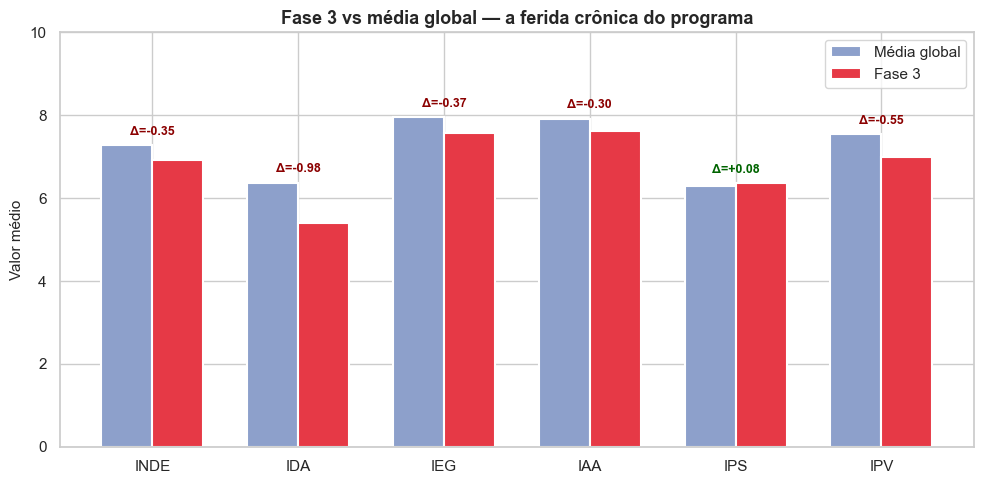

In [17]:
# Visualização: radar da fase 3 vs global
indicadores = ["inde", "ida", "ieg", "iaa", "ips", "ipv"]
medias_globais = [alunos[i].mean() for i in indicadores]
medias_f3 = [f3[i].mean() for i in indicadores]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(indicadores))
width = 0.35

bars1 = ax.bar(x - width/2, medias_globais, width, label="Média global",
               color="#8da0cb", edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + width/2, medias_f3, width, label="Fase 3",
               color="#e63946", edgecolor="white", linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels([i.upper() for i in indicadores])
ax.set_ylabel("Valor médio")
ax.set_title("Fase 3 vs média global — a ferida crônica do programa",
             fontweight="bold")
ax.set_ylim(0, 10)
ax.legend()

# Anotar deltas
for i, (g, f) in enumerate(zip(medias_globais, medias_f3)):
    delta = f - g
    cor_txt = "darkred" if delta < -0.3 else "darkgreen" if delta > 0 else "gray"
    ax.text(i, max(g, f) + 0.25, f"Δ={delta:+.2f}",
            ha="center", fontsize=9, fontweight="bold", color=cor_txt)

plt.tight_layout()
salvar_figura("p11_crise_fase3")
plt.show()

In [18]:
# Taxa de sobrevivência específica da fase 3
ra_f3_22 = set(f3[f3.ano == 2022].ra)
ra_em_24 = ra_f3_22 & set(alunos[alunos.ano == 2024].ra)
print(f"Fase 3 em 2022: {len(ra_f3_22)} alunos")
print(f"Ainda no programa em 2024: {len(ra_em_24)} ({len(ra_em_24)/len(ra_f3_22)*100:.1f}%)")
print(f"Taxa de evasão: {(len(ra_f3_22)-len(ra_em_24))/len(ra_f3_22)*100:.1f}%")

Fase 3 em 2022: 148 alunos
Ainda no programa em 2024: 67 (45.3%)
Taxa de evasão: 54.7%


###  interpretação da fase 3

a fase 3 é o "vale da morte" do programa:
- IDA -0.98 abaixo da média (maior gap de todos)
- IPV -0.55 abaixo
- 54.7% sobreviveram até 2024 (taxa de evasão de 45%)
- única fase onde IPS está acima da média (+0.08) — o psicólogo vê eles bem, mas a realidade acadêmica diz o contrário

por que isso é estrutural: a fase 3 corresponde ao 7º-8º ano do ensino fundamental. é a idade de 12-14 anos — entrada na adolescência, explosão hormonal, mudança abrupta da matemática concreta pra abstrata (álgebra), pressão social crescente. é um ponto de inflexão conhecido da educação brasileira em geral — não é específico da Passos.

mas o dado mostra que o programa atual não está preparado pra enfrentar isso. os indicadores psicossociais (IPS, IAA) não capturam a dificuldade — é um fenômeno puramente acadêmico (IDA) combinado com desengajamento (IEG). a resposta precisa ser pedagógica específica, não emocional.

### 11.2 o vácuo do ensino superior

In [19]:
# Evolução da presença de alunos do ensino superior
print("Alunos no ensino superior (fases 8 e 9) por ano:")
for ano in [2022, 2023, 2024]:
    sub = alunos[alunos.ano == ano]
    f8 = (sub["fase"] == 8).sum()
    f9 = (sub["fase"] == 9).sum()
    print(f"  {ano}: {f8 + f9:4d} total  (fase 8: {f8}, fase 9: {f9})")

# Em 2024, quantos têm indicadores preenchidos?
sup_24 = alunos[(alunos.ano == 2024) & (alunos["fase"].isin([8, 9]))]
print(f"\nDos {len(sup_24)} universitários em 2024:")
for ind in ["inde", "pedra", "ida", "ieg", "ipv", "ipp"]:
    preenchidos = sup_24[ind].notna().sum()
    pct = preenchidos / len(sup_24) * 100
    print(f"  {ind.upper():6s}: {preenchidos:3d}/{len(sup_24)} ({pct:5.1f}%)")

Alunos no ensino superior (fases 8 e 9) por ano:
  2022:    0 total  (fase 8: 0, fase 9: 0)
  2023:   63 total  (fase 8: 63, fase 9: 0)
  2024:  102 total  (fase 8: 64, fase 9: 38)

Dos 102 universitários em 2024:
  INDE  :   0/102 (  0.0%)
  PEDRA :   0/102 (  0.0%)
  IDA   :   1/102 (  1.0%)
  IEG   : 102/102 (100.0%)
  IPV   :   0/102 (  0.0%)
  IPP   :   0/102 (  0.0%)


Dos 102 universitários em 2024:
  Já estavam no programa em 2022: 27
  Entraram em 2023:               46
  Totalmente novos em 2024:       29
  💾 reports/figures/p11_vacuo_ensino_superior.png


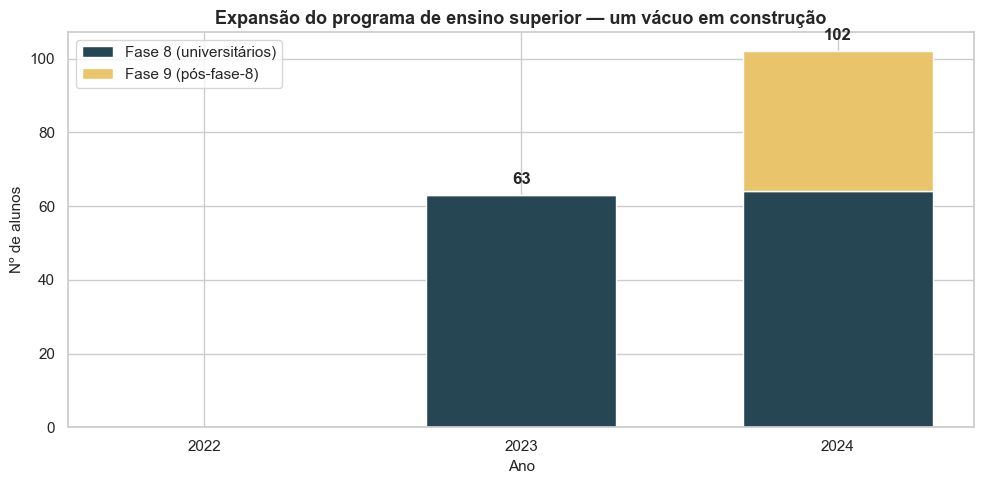

In [20]:
# Dos universitários em 2024, quantos vieram de ANTES (alunos da Passos históricos)
ra_sup_24 = set(sup_24["ra"])
ra_22 = set(alunos[alunos.ano == 2022].ra)
ra_23 = set(alunos[alunos.ano == 2023].ra)

eram_de_22 = ra_sup_24 & ra_22
eram_de_23 = ra_sup_24 & ra_23
novos_em_24 = ra_sup_24 - ra_22 - ra_23

print(f"Dos {len(ra_sup_24)} universitários em 2024:")
print(f"  Já estavam no programa em 2022: {len(eram_de_22)}")
print(f"  Entraram em 2023:               {len(eram_de_23 - ra_22)}")
print(f"  Totalmente novos em 2024:       {len(novos_em_24)}")

# Visualização: evolução do programa de ensino superior
fig, ax = plt.subplots(figsize=(10, 5))
anos = [2022, 2023, 2024]
fase_8 = [(alunos[alunos.ano == a]["fase"] == 8).sum() for a in anos]
fase_9 = [(alunos[alunos.ano == a]["fase"] == 9).sum() for a in anos]

ax.bar(anos, fase_8, label="Fase 8 (universitários)", color="#264653", width=0.6)
ax.bar(anos, fase_9, bottom=fase_8, label="Fase 9 (pós-fase-8)", color="#e9c46a", width=0.6)

for i, (a, f8, f9) in enumerate(zip(anos, fase_8, fase_9)):
    total = f8 + f9
    if total > 0:
        ax.text(a, total + 3, f"{total}", ha="center", fontweight="bold", fontsize=12)

ax.set_title("Expansão do programa de ensino superior — um vácuo em construção",
             fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de alunos")
ax.set_xticks(anos)
ax.legend()
plt.tight_layout()
salvar_figura("p11_vacuo_ensino_superior")
plt.show()

###  interpretação do vácuo do ensino superior

os números contam uma história clara:

- 2022: 0 alunos no ensino superior
- 2023: 63 alunos (só fase 8)
- 2024: 102 alunos (fase 8 + nova fase 9 criada)

dos 102 universitários em 2024:

- INDE preenchido: 0 (0%) 
- pedra atribuída: 0 (0%) 
- IDA preenchido: 1 (1%) 
- IEG preenchido: 102 (100%) — só isso

a Passos Mágicos criou um programa de continuidade universitária sem criar o instrumento de avaliação correspondente. ela está coletando algum sinal (IEG), mas nem de longe o suficiente pra medir impacto.

por que isso aconteceu: porque o PEDE foi desenhado pra ensino fundamental e médio (pedras Quartzo-Topázio associadas a notas escolares, fase ideal associada a idade/série). nada disso faz sentido pra universitário, então a ONG simplesmente não aplica a avaliação.

###  o que isso significa pra Passos Mágicos

> a Passos amadureceu junto com seus alunos. a ONG começou com foco em crianças e agora está formando a primeira geração de universitários — um marco histórico. mas está voando cego nesse novo pedaço do programa porque não tem instrumento de avaliação apropriado.

> recomendação executiva (a mais disruptiva do projeto):
>
> a Passos precisa criar um PEDE-superior — uma versão do instrumento adaptada pra ensino superior. indicadores possíveis:
> - desempenho universitário: cr, aprovação em disciplinas-chave
> - engajamento: frequência em mentorias, participação em grupos de estudo
> - empregabilidade: estágios conquistados, networking profissional
> - impacto de longo prazo: egressos que retornam como mentores
>
> sem isso, daqui a 5 anos a Passos não vai ter dados pra provar (pra doadores, pra sociedade, pra si mesma) que o programa universitário funcionou. essa é uma recomendação que vem dos dados, mas tem implicação estratégica imediata.

---

##  resumo da etapa 3b

### os 5 grandes achados das perguntas 7-11

| # | achado | magnitude |
|---|---|---|
| p7 | IDA, IEG, IPV e IPP (crescendo) são os preditores do IPV. IPS e IAA contribuem quase nada. | features do modelo da etapa 4 |
| p8 | descobri a fórmula oficial do INDE via regressão linear: IDA/IEG/IPV pesam 20% cada, os outros 4 pesam 10%. sem atalho pro top25. | validação estrutural |
| p9 | transições quase simétricas (25/50/25). 6× mais evasão no Quartzo. o programa mantém quem já está bem. | alerta estratégico |
| p10 |  evasão é previsível: IEG e IDA baixos, Quartzo, fase 3 ou 7. 59% dos Quartzo evadem. | justifica o modelo preditivo |
| p11 |  fase 3 é o vale da morte (IDA -0.98). ensino superior cresceu de 0 → 102 alunos em 2 anos, sem instrumento de avaliação. | recomendações disruptivas |

###  os 3 insights mais acionáveis do projeto inteiro (parte 1 + parte 2)

1. p4 — dunning-kruger confirmado: 65% dos alunos superestimam seu desempenho. quem está pior é quem mais superestima. implicação pedagógica direta: feedback explícito e frequente.

2. p10 — evasão previsível: o modelo da etapa 4 pode salvar dezenas de alunos/ano identificando risco antes da evasão acontecer. justificativa direta pro coração técnico do projeto.

3. p11 — vácuo do ensino superior: recomendação estratégica disruptiva — a Passos precisa criar um PEDE-superior pra não perder a capacidade de medir seu próprio impacto no novo público.

###  etapa 3 completa — o que tenho agora
-  11 perguntas respondidas
-  ~15 figuras prontas pra apresentação em `reports/figures/`
-  lista clara de features prioritárias pro modelo preditivo (IEG, IDA, IPV, IPP, IAN e deltas)
-  definição do target de risco com justificativa empírica forte
-  narrativa de negócio estruturada pro storytelling executivo

### próximo passo
etapa 4 — feature engineering e modelagem preditiva (`03_feature_engineering.ipynb` e `04_modelagem.ipynb`).